# SpecLive — Inference Explorer

The **backend view** of what SpecLive infers from a discovery transcript, as data.

This notebook drives the *real* derivation pipeline (`AnalysisService` +
a `LanguageModelProvider` + a `ContextStrategy` — the same code the app runs)
over a labeled corpus transcript, then reshapes the result into three
`pandas` DataFrames you can slice, score, and visualize:

| view | grain | answers |
|------|-------|---------|
| **inference ledger** | one row per *derived artifact* | *what* was inferred, *from which words*, with *what confidence*, and *what type* |
| **segment coverage** | one row per *transcript turn* | what's **inferred vs. not** |
| **dependencies** | one edge per *artifact pair* | **reinforcement** vs. **conflict** across time |

Nothing here re-derives anything — it only reshapes what the pipeline produced,
so the numbers stay faithful to the actual methodology.

### The inference-ledger columns

| column | meaning |
|--------|---------|
| `case` / `provider` / `strategy` | which run produced this row |
| `artifact_id` | stable id of the inferred artifact |
| **`artifact_type`** | *what it was inferred to be* — one of SpecLive's canonical types (objective, stakeholder_need, requirement, constraint, assumption, risk, decision, open_question, success_metric, integration, stakeholder) |
| `title` / `statement` | the inferred artifact |
| **`confidence`** | model/heuristic confidence, 0–1 |
| `derivation_method` | `keyword_heuristic` \| `llm` \| `manual` |
| `validation_state` | lifecycle: `detected` → `inferred` → `clarified` → `customer_confirmed` → … (the "inferred vs. confirmed" axis) |
| `status` | UI rollup badge |
| `evidence_count` | how many transcript spans support it |
| **`segment_seq`** | *which portion of text* — the turn index of the strongest evidence |
| **`start_time` / `end_time`** | *time* of that turn (seconds from session start) |
| `speaker` / `speaker_name` | who said it |
| **`evidence_quote`** | the exact quoted span |
| `evidence_relationship` | `direct` \| `supporting` \| `contradicting` \| `superseding` \| `contextual` |
| `segment_text` | full text of the source turn |
| **`depends_on` / `dependency_kind`** | *other dependent time-things* — linked artifacts and whether the link is `reinforcement`, `conflict`, or `related` |
| `matched_gold_id` / `gold_type` / `correct_type` / `quote_grounded` | *(optional)* evaluation against the hand-authored ground truth |

> The column contract lives in `research/harness/frames.py`
> (`LEDGER_COLUMNS`, `SEGMENT_COLUMNS`, `DEPENDENCY_COLUMNS`) — edit it there and
> both this notebook and any future exporter stay in sync.

## 1 · Setup & configuration

Pick the case, provider, and context strategy to explore.

In [1]:
import sys
from pathlib import Path

# Put the harness on the path; _bootstrap wires the real services against a
# throwaway SQLite DB and adds apps/api to sys.path (import it FIRST).
HARNESS = Path.cwd().parents[0] / "harness" if (Path.cwd().name == "notebooks") else Path.cwd() / "research" / "harness"
HARNESS = HARNESS.resolve()
sys.path.insert(0, str(HARNESS))

import pandas as pd

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

# --- knobs -----------------------------------------------------------------
CASE = "hospital-bed-mgmt"    # any dir under research/corpus with transcript.json + gold.json
PROVIDER = "mock"             # "mock" (no keys) | "openai_compatible" (needs LLM_API_KEY)
STRATEGY = "full"            # "segment" | "window" | "full"  (how much context each call sees)
MATCHER = "lexical"          # "lexical" | "embedding" — only used for the optional gold scoring
THRESHOLD = 0.30

print(f"harness: {HARNESS}")
print(f"run: case={CASE!r} provider={PROVIDER!r} strategy={STRATEGY!r}")

harness: /home/user/SpecLive/research/harness
run: case='hospital-bed-mgmt' provider='mock' strategy='full'


## 2 · Drive the real pipeline

`ingest` the transcript into a live session, run `AnalysisService.analyze_session`, then collect the derived artifacts, their evidence links, and the ordered segments.

In [2]:
import json

import ingest as ingest_mod
from _bootstrap import make_context, provider_available

REPO_ROOT = HARNESS.parents[1]
CORPUS = REPO_ROOT / "research" / "corpus"

ok, why = provider_available(PROVIDER)
assert ok, f"provider {PROVIDER!r} unavailable: {why}"

case_dir = CORPUS / CASE
transcript = ingest_mod.load_transcript(case_dir / "transcript.json")
gold_path = case_dir / "gold.json"
gold = json.loads(gold_path.read_text())["gold_artifacts"] if gold_path.exists() else None

ctx = make_context(PROVIDER, STRATEGY)
try:
    segments = ingest_mod.ingest(ctx, transcript)          # turn-ordered
    ctx.analysis.analyze_session(ctx.session_id)            # the real derivation
    derived = ctx.artifacts.list_for_session(ctx.session_id)
    evidence_by_artifact = {a.id: ctx.artifacts.evidence_for(a.id) for a in derived}
finally:
    ctx.close()

print(f"{len(segments)} segments · {len(derived)} artifacts derived · "
      f"{sum(len(v) for v in evidence_by_artifact.values())} evidence links")

8 segments · 6 artifacts derived · 6 evidence links


## 3 · The inference ledger

One row per inferred artifact, traced to the transcript span it came from — plus cross-artifact dependency links and (when a gold file exists) evaluation columns.

In [3]:
import frames

ledger = frames.build_ledger(
    case=CASE, provider=PROVIDER, strategy=STRATEGY,
    derived=derived, evidence_by_artifact=evidence_by_artifact, segments=segments,
)

# cross-artifact dependencies: reinforcement vs. conflict vs. related
deps = frames.detect_dependencies(derived=derived, evidence_by_artifact=evidence_by_artifact)
ledger = frames.attach_dependencies(ledger, deps)

# optional: fold in gold matches for evaluation columns
if gold is not None:
    import match as match_mod, score as score_mod
    from _bootstrap import build_embedder
    matcher = match_mod.get_matcher(MATCHER, embedder=build_embedder() if MATCHER == "embedding" else None)
    pairs = matcher.match(derived, gold, evidence_by_artifact, threshold=THRESHOLD)
    ledger = frames.attach_gold(ledger, derived=derived, gold=gold, pairs=pairs,
                                evidence_by_artifact=evidence_by_artifact)

print(f"ledger: {len(ledger)} rows × {len(ledger.columns)} cols")
ledger[["segment_seq", "start_time", "speaker_name", "artifact_type",
        "confidence", "evidence_quote", "dependency_kind", "correct_type"]]

ledger: 6 rows × 26 cols


,segment_seq,start_time,speaker_name,artifact_type,confidence,evidence_quote,dependency_kind,correct_type
0,3,90.0,Dr. Naomi Fields,constraint,0.77,go-live,NaN,NaN
1,4,120.0,Dr. Naomi Fields,constraint,0.82,handheld,related,NaN
2,4,120.0,Dr. Naomi Fields,integration,0.66,integrat,reinforcement,NaN
3,5,150.0,Dr. Naomi Fields,integration,0.62,api,reinforcement,NaN
4,7,210.0,Dr. Naomi Fields,integration,0.66,integrat,reinforcement,NaN
5,7,210.0,Dr. Naomi Fields,success_metric,0.63,success,related,NaN


In [4]:
# full detail for one artifact
if len(ledger):
    ledger.iloc[[0]].T

## 4 · Segment coverage — *what's inferred, what's not*

One row per transcript turn, flagged with whether anything was inferred from it.

In [5]:
coverage = frames.build_segment_coverage(
    derived=derived, evidence_by_artifact=evidence_by_artifact, segments=segments,
)
pct = 100 * coverage["inferred"].mean() if len(coverage) else 0.0
print(f"{coverage['inferred'].sum()}/{len(coverage)} segments produced at least one artifact "
      f"({pct:.0f}% coverage)")
coverage[["segment_seq", "start_time", "speaker_name", "inferred",
          "artifact_count", "artifact_types", "text"]]

4/8 segments produced at least one artifact (50% coverage)


,segment_seq,start_time,speaker_name,inferred,artifact_count,artifact_types,text
0,0,0.0,Dr. Naomi Fields,False,0,[],"Good morning, everyone. Today I want to walk you through a real problem I'm ..."
1,1,30.0,Dr. Naomi Fields,False,0,[],"Let me describe how bed assignment actually works today, because it's more m..."
2,2,60.0,Dr. Naomi Fields,False,0,[],The exceptions are where it really falls apart. Isolation patients need a sp...
3,3,90.0,Dr. Naomi Fields,True,1,[constraint],"So here's what I need this system to actually move. First, average ER boardi..."
4,4,120.0,Dr. Naomi Fields,True,2,"[constraint, integration]","On the technical side, everything has to integrate with our existing Epic EH..."
5,5,150.0,Dr. Naomi Fields,True,1,[integration],"Now, constraints, and there are some real ones. This is a HIPAA environment,..."
6,6,180.0,Dr. Naomi Fields,False,0,[],"A couple of things I genuinely don't have answers to yet, and I want to flag..."
7,7,210.0,Dr. Naomi Fields,True,2,"[integration, success_metric]","Let me just play back what I've described, because I want you to practice pu..."


## 5 · Visualize — inference timeline

Each turn on a time axis; filled markers are turns something was inferred from, sized by artifact count and colored by speaker. This is the transcript-level *inferred vs. not* picture.

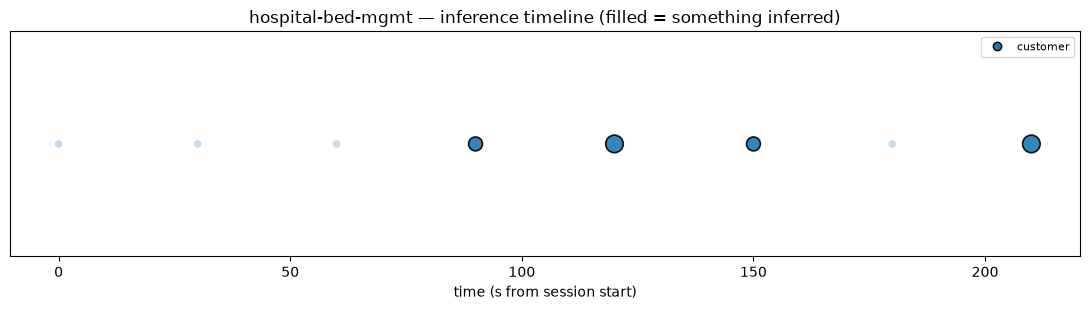

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 3.2))
c = coverage
speakers = list(dict.fromkeys(c["speaker"]))
palette = {sp: col for sp, col in zip(speakers, plt.cm.tab10.colors)}
for inferred, marker in [(False, "o"), (True, "o")]:
    sub = c[c["inferred"] == inferred]
    ax.scatter(
        sub["start_time"], [1] * len(sub),
        s=[40 + 60 * n for n in sub["artifact_count"]] if inferred else 30,
        c=[palette[s] for s in sub["speaker"]],
        edgecolors="black" if inferred else "none",
        linewidths=1.2 if inferred else 0,
        alpha=0.9 if inferred else 0.25,
        zorder=3 if inferred else 2,
    )
ax.set_yticks([]); ax.set_xlabel("time (s from session start)")
ax.set_title(f"{CASE} — inference timeline (filled = something inferred)")
handles = [plt.Line2D([], [], marker="o", ls="", mfc=palette[s], mec="black", label=s) for s in speakers]
ax.legend(handles=handles, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

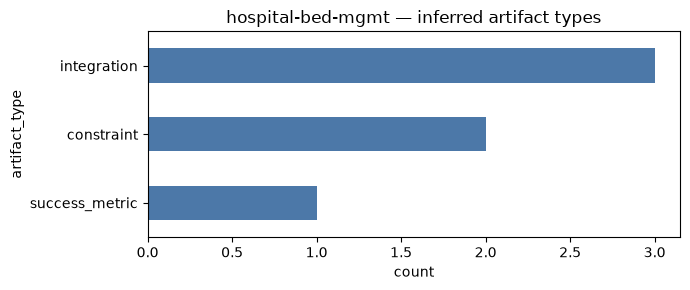

In [7]:
# artifact-type distribution (what kinds of things got inferred)
if len(ledger):
    counts = ledger["artifact_type"].value_counts()
    ax = counts.plot(kind="barh", figsize=(7, 3), color="#4C78A8")
    ax.invert_yaxis(); ax.set_xlabel("count"); ax.set_title(f"{CASE} — inferred artifact types")
    plt.tight_layout(); plt.show()
    counts

## 6 · Visualize — dependency graph

Artifacts as nodes (colored by type), dependency links as edges: **green = reinforcement**, **red = conflict**, **grey = related**. This is the SpecLive "connections" view — how inferences relate across the conversation.

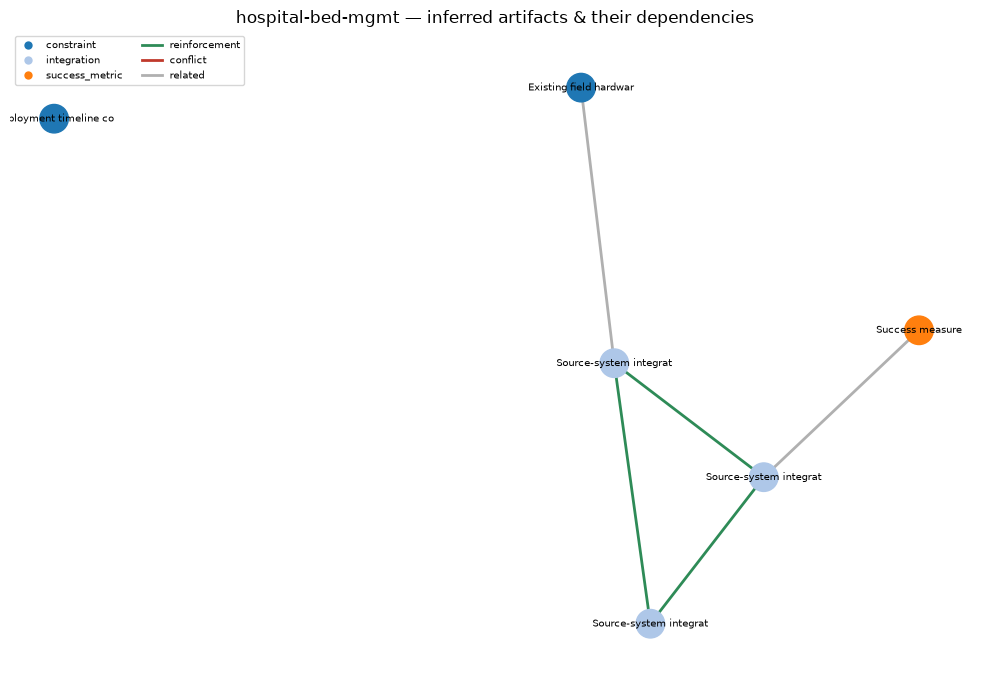

,kind,score,basis,source_type,target_type,source_title,target_title
0,related,0.150,shared_segment,constraint,integration,Existing field hardware,Source-system integration
1,reinforcement,1.000,same_type+similarity=1.00,integration,integration,Source-system integration,Source-system integration
2,reinforcement,1.000,same_type+similarity=1.00,integration,integration,Source-system integration,Source-system integration
3,reinforcement,1.000,same_type+similarity=1.00,integration,integration,Source-system integration,Source-system integration
4,related,0.111,shared_segment,integration,success_metric,Source-system integration,Success measure


In [8]:
import networkx as nx

if len(deps):
    G = nx.Graph()
    for _, r in ledger.iterrows():
        G.add_node(r.artifact_id, type=r.artifact_type)
    edge_color = {"reinforcement": "#2E8B57", "conflict": "#C0392B", "related": "#B0B0B0"}
    for _, e in deps.iterrows():
        G.add_edge(e.source_id, e.target_id, color=edge_color.get(e.kind, "#B0B0B0"), kind=e.kind)

    types = sorted({d["type"] for _, d in G.nodes(data=True)})
    tcol = {t: c for t, c in zip(types, plt.cm.tab20.colors)}
    pos = nx.spring_layout(G, seed=7, k=0.9)
    fig, ax = plt.subplots(figsize=(10, 7))
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=[G[u][v]["color"] for u, v in G.edges()], width=2)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=420,
                           node_color=[tcol[G.nodes[n]["type"]] for n in G.nodes()])
    labels = {r.artifact_id: (r.title[:22] if r.title else r.artifact_type) for _, r in ledger.iterrows()}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7)
    handles = ([plt.Line2D([], [], marker="o", ls="", mfc=tcol[t], mec="none", label=t) for t in types]
               + [plt.Line2D([], [], color=edge_color[k], lw=2, label=k) for k in edge_color])
    ax.legend(handles=handles, loc="upper left", fontsize=7, ncol=2)
    ax.set_axis_off(); ax.set_title(f"{CASE} — inferred artifacts & their dependencies")
    plt.tight_layout(); plt.show()
    display(deps[["kind", "score", "basis", "source_type", "target_type", "source_title", "target_title"]])
else:
    print("No dependency edges found for this run (try STRATEGY='full' or a case with more artifacts).")

## 7 · Where this goes next

This notebook is the exploration surface; `research/harness/frames.py` is the reusable
backend. Natural extensions:

1. **Sweep, don't pick.** Loop `frames.build_ledger` over `provider × strategy` and
   `pd.concat` — one tall ledger to compare methodologies side by side (the sweep
   `run.py` already does at the *metrics* level; this adds the per-artifact detail).
2. **Real conflict detection.** `detect_dependencies` is a transparent lexical v1.
   Replace it with a model pass (or a negation-aware signal) so `conflict` means a
   genuine contradiction, not just "same type, similar words."
3. **Export.** The three DataFrames are the natural payload for a SpecLive backend
   endpoint feeding the inference UI — `frames.py` is written to be imported by
   `app`-side code, not just the notebook.
4. **Real LLM.** Set `LLM_API_KEY` / `LLM_API_BASE` / `LLM_MODEL`, flip
   `PROVIDER = "openai_compatible"`, and re-run the identical corpus to see the
   ledger fill out beyond the keyword mock's reach.